In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS']      = '1'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math, json, datetime
from scipy import signal

In [2]:
TEST    = json.loads(open('../info.json', 'r').read()).get('test', 1)
SOURCE  = f'../Dataset/test{TEST}/files/data.csv'
DATASET = 'Backup/target.csv'
RESULTS = f'../Dataset/test{TEST}/results'

print('SOURCE:', SOURCE)

SOURCE: ../Dataset/test1/files/data.csv


# IMPORTANDO DADOS
Saída do ensaio de pêndulo: cada amostra traz a IMU em teste (`target_`) e a MRU de referência (`ref_`) já alinhadas no mesmo instante.

In [3]:
df = pd.read_csv(SOURCE)
print(len(df), 'linhas')
df.head()

1801 linhas


,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,...,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,...,9.59,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,...,10.54,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,...,11.46,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,...,12.17,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,...,12.51,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821


# DEFASAGEM
- Atraso da IMU em teste contra a MRU de referência: pico da correlação cruzada do roll, só no trecho em movimento (`static` falso)
- Todas as colunas `target_` andam juntas, sem atravessar o buraco da gravação; as amostras que ficam sem par saem

In [4]:
# ATRASO DA IMU EM TESTE CONTRA A REFERÊNCIA PELO PICO DA CORRELAÇÃO CRUZADA
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df, var):
        if df.empty:
            return 0

        x = df[self.target + var]
        y = df[self.reference + var]

        correlation = np.correlate(y - y.mean(), x - x.mean(), mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        return lags[np.argmax(correlation)]

    def set(self, df, lag):
        columns = df.filter(regex=f'^{self.target}').columns
        step    = df.time.diff()
        block   = (step > 1.5*step.median()).cumsum()    # O DESLOCAMENTO NÃO ATRAVESSA O BURACO DA GRAVAÇÃO

        df[columns] = df.groupby(block)[columns].shift(lag)
        return df.dropna(subset=columns).reset_index(drop=True)


phaser = Phaser('target_', 'ref_')
lag    = phaser.get(df[~df.static], 'wx')
df     = phaser.set(df, lag)
print('defasagem:', lag, 'amostras |', len(df), 'linhas')

defasagem: 0 amostras | 1801 linhas


# RENOMEANDO COLUNAS

In [5]:
SENSORS = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']
df = df.rename(columns={f'target_{var}': var for var in SENSORS})
df = df[['time', 'static'] + SENSORS]
df

,time,static,ax,ay,az,wx,wy,wz
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709
...,...,...,...,...,...,...,...,...
1796,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493
1797,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338
1798,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588
1799,279.8,True,0.222170,9.755871,-0.409330,-0.01801,-0.00522,0.04660


# PERÍODO DE AMOSTRAGEM
- Verificando a distribuição do período para verificar número de outliers

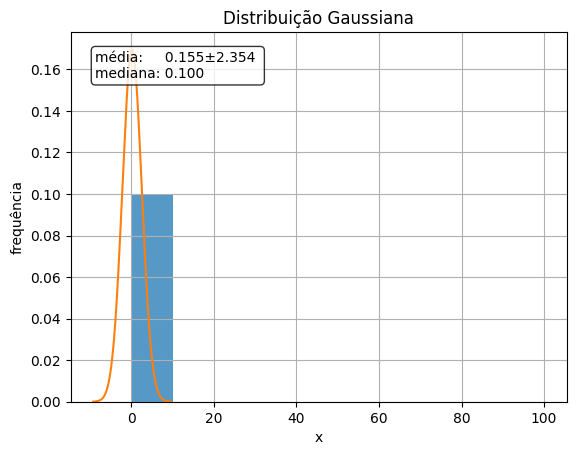

2799 amostras na grade de 0.1 s


,time,static,ax,ay,az,wx,wy,wz
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709
...,...,...,...,...,...,...,...,...
2794,279.4,True,0.269369,9.760873,-0.416959,-0.09321,0.25104,-0.21920
2795,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493
2796,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338
2797,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588


In [6]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)

    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

# GRADE E LEITURAS ARREDONDADAS NA MESMA CASA: SEM ISSO O RUÍDO DE FLOAT (1e-14) FAZ O merge_asof SEGURAR A AMOSTRA ANTERIOR
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = (df[key] - df[key].iloc[0]).round(10)

    n = int(np.floor(df[key].iloc[-1] / dt)) + 1
    newAxis = np.round(np.linspace(0, dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    return pd.merge_asof(target, df, on=key, direction='backward')


time = df.time.diff()[1:].to_numpy()
dt   = 0.1

gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
print(len(df), 'amostras na grade de', dt, 's')
df

# SALVANDO DADOS

In [7]:
os.makedirs('Backup', exist_ok=True)

df.to_csv(DATASET, index=None)
pd.read_csv(DATASET).head()

,time,static,ax,ay,az,wx,wy,wz
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709


# VISUALIZAÇÃO DOS DADOS

In [8]:
MOTION = (~df.static)
LIMITS = (40, 60)
df

,time,static,ax,ay,az,wx,wy,wz
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709
...,...,...,...,...,...,...,...,...
2794,279.4,True,0.269369,9.760873,-0.416959,-0.09321,0.25104,-0.21920
2795,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493
2796,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338
2797,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588


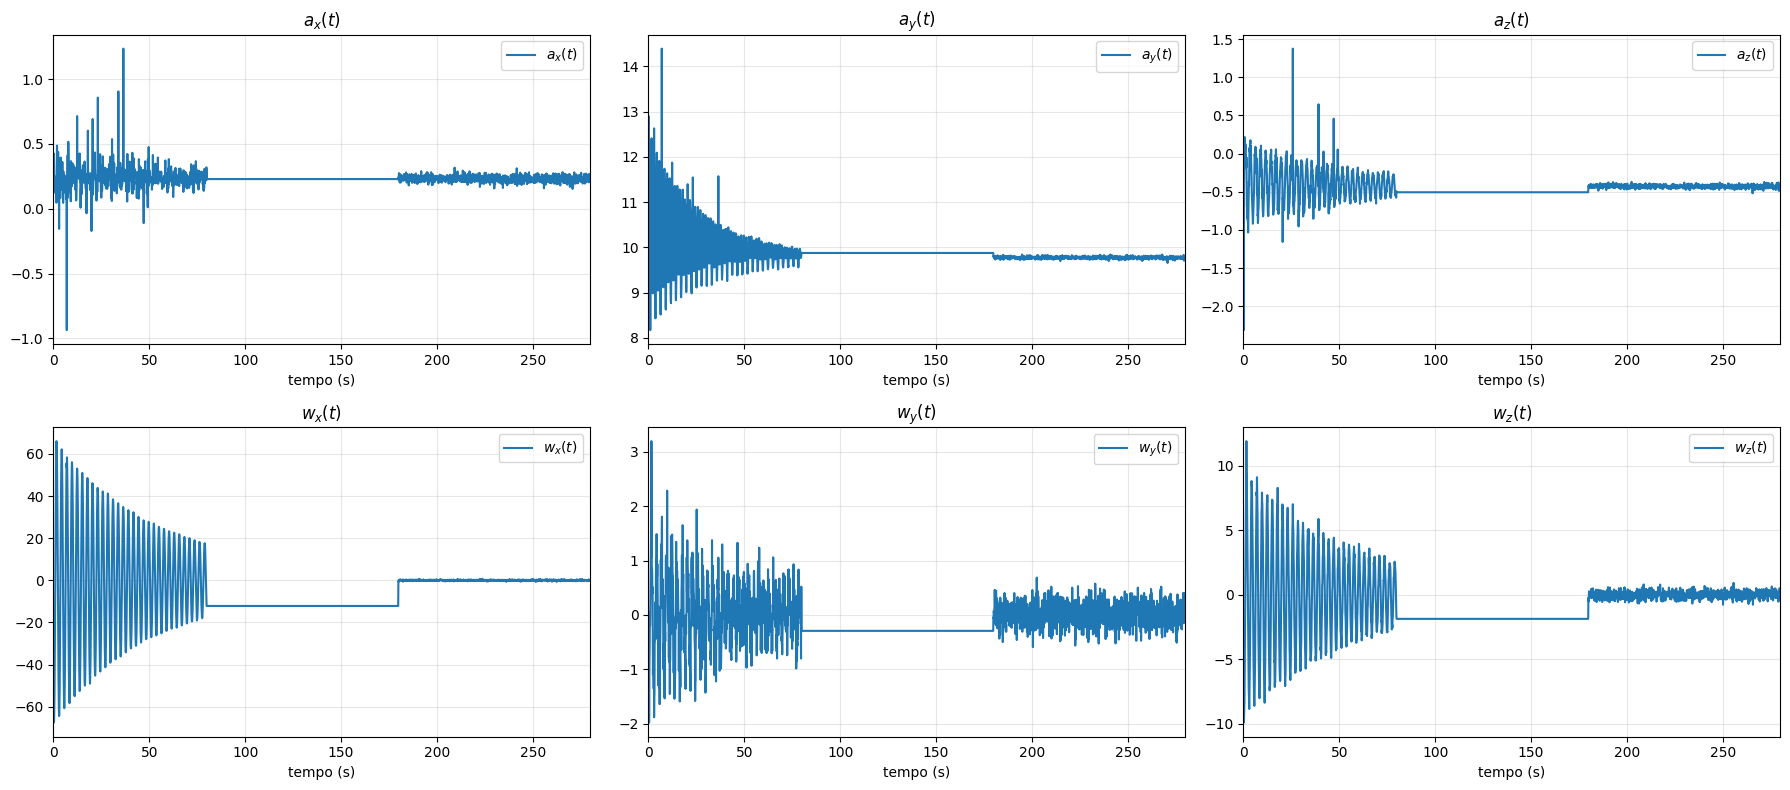

In [9]:
# GRADE DE SUBPLOTS RECORTADA POR FRAÇÃO DO TEMPO TOTAL
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)

    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])

    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)

        plt.subplot(numRows, numCols, i+1)
        plt.plot(time[mask], values[mask], label=key)

        plt.xlim(start_time, end_time)
        if yLim: plt.ylim(yLim)
        plt.title(key); plt.xlabel('tempo (s)')
        plt.grid(alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.show()


# PAINEL PADRÃO: ACELERÔMETRO E GIROSCÓPIO
def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz
    }, limits)


plotAll(df, limits=(0, 1))

# FILTROS
### PASSA BAIXA
- Quatro polos reais em $2\pi F_c$ por Tustin, o mesmo `LowPassFilter` do firmware: o −3 dB cai em $\approx 0{,}435\,F_c$, não em $F_c$

In [10]:
# QUATRO POLOS REAIS EM Fc POR TUSTIN, ESPELHO DO FIRMWARE
class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc

        Wc = (2 * np.pi * Fc)
        num_c = [Wc**4]
        den_c = [1, 4*Wc, 6*(Wc**2), 4*(Wc**3), Wc**4]

        C = signal.cont2discrete((num_c, den_c), dt, method='bilinear')
        self.num, self.den = self.getFraction(C)
        self.reset()

    def getFraction(self, C):
        num = np.squeeze(C[0])
        den = np.squeeze(C[1])
        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        return np.dot(self.Xn, self.num) - np.dot(self.Yn[1:], self.den[1:])

    def update(self, inputValue):
        self.Xn[1:] = self.Xn[:-1].copy()
        self.Yn[1:] = self.Yn[:-1].copy()
        self.Xn[0]  = inputValue
        self.Yn[0]  = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    # ESTADOS NO VALOR INICIAL: REGIME PERMANENTE, SEM O TRANSITÓRIO DE PARTIDA DO ZERO
    def reset(self, value=0.0):
        self.Xn = np.full(len(self.num), value)
        self.Yn = np.full(len(self.den), value)

    def apply(self, yData):
        yData = np.asarray(yData, dtype=float)
        self.reset(yData[0] if len(yData) else 0.0)
        return np.array([self.update(value) for value in yData])

    # DESENHA NO EIXO QUE O CHAMADOR ABRIU
    def test(self, df, var, limits):
        window   = (df.time >= limits[0]) & (df.time <= limits[1])
        filtered = self.apply(df[var])

        plt.scatter(df.time[window], df[var][window], label='bruto', s=5, color='orange')
        plt.plot(df.time[window], filtered[window], label=f'Fc={self.Fc:.3g} Hz', linewidth=2)
        plt.title('Filtro Passa Baixa (Valores)'); plt.xlabel('tempo (s)'); plt.ylabel(var); plt.grid(alpha=0.3); plt.legend(loc='upper right')
        return filtered

### FILTRO DE BUTTERWORTH
- Segunda ordem por Tustin com pré-distorção, o mesmo `ButterworthFilter` do firmware: `f_c` é fração de Nyquist, então `f_c = 0.3` corta em 1,5 Hz

In [11]:
# BUTTERWORTH DE SEGUNDA ORDEM COM PRÉ-DISTORÇÃO, ESPELHO DO FIRMWARE
class ButterworthFilter:
    def __init__(self, f_c):
        self.f_c = f_c / 2.0
        self.b, self.a = self.getCoefs()
        self.reset()

    def getCoefs(self):
        wc = math.tan(math.pi * self.f_c)
        c2 = wc*wc
        norm = 1 + math.sqrt(2)*wc + c2

        b0 = c2/norm
        b1 = 2*c2/norm
        b2 = c2/norm

        a1 = 2*(c2 - 1)/norm
        a2 = (1 - math.sqrt(2)*wc + c2)/norm
        return [b0, b1, b2], [1.0, -a1, -a2]

    def update(self, Xn):
        Yn = self.b[0]*Xn + self.b[1]*self.Xn1 + self.b[2]*self.Xn2 + self.a[1]*self.Yn1 + self.a[2]*self.Yn2
        self.Xn2, self.Xn1 = self.Xn1, Xn
        self.Yn2, self.Yn1 = self.Yn1, Yn
        return Yn

    def reset(self, value=0.0):
        self.Xn1 = self.Xn2 = value
        self.Yn1 = self.Yn2 = value

    def apply(self, data):
        data = np.asarray(data, dtype=float)
        self.reset(data[0] if len(data) else 0.0)
        return np.array([self.update(value) for value in data])

    # DESENHA NO EIXO QUE O CHAMADOR ABRIU
    def test(self, df, var, limits):
        window   = (df.time >= limits[0]) & (df.time <= limits[1])
        filtered = self.apply(df[var])

        plt.scatter(df.time[window], df[var][window], label='bruto', s=5, color='orange')
        plt.plot(df.time[window], filtered[window], label=f'f_c={2*self.f_c:.3g}', linewidth=2)
        plt.title('Butterworth (Valores)'); plt.xlabel('tempo (s)'); plt.ylabel(var); plt.grid(alpha=0.3); plt.legend(loc='upper right')
        return filtered

### FILTRO DE MÉDIA EXPONENCIAL

In [12]:
# PRIMEIRA ORDEM y = αx + (1 − α)y₋₁
class ExponentialFilter:
    def __init__(self, alpha):
        self.alpha = alpha

    def apply(self, data):
        return pd.Series(np.asarray(data, dtype=float)).ewm(alpha=self.alpha, adjust=False).mean().to_numpy()

    # DESENHA NO EIXO QUE O CHAMADOR ABRIU
    def test(self, df, var, limits):
        window   = (df.time >= limits[0]) & (df.time <= limits[1])
        filtered = self.apply(df[var])

        plt.scatter(df.time[window], df[var][window], label='bruto', s=5, color='orange')
        plt.plot(df.time[window], filtered[window], label=f'α={self.alpha:.3g}', linewidth=2)
        plt.title('Média Exponencial (Valores)'); plt.xlabel('tempo (s)'); plt.ylabel(var); plt.grid(alpha=0.3); plt.legend(loc='upper right')
        return filtered

# OTIMIZAÇÃO DOS PARÂMETROS
- A `objective` devolve $\varepsilon$, o erro RMS entre o filtrado e o movimento verdadeiro **no mesmo instante**, dividido pelo erro do sinal cru: o atraso entra no erro, porque é o que o firmware entrega
- No trecho em movimento o espectro de Welch é sinal mais ruído, $P = S + N$. O pêndulo ocupa poucas raias, então a mediana de $P$ é o piso $N$ e $S = \max(P - N,\ 0)$
- Todo filtro aqui é linear e fica descrito pela resposta $H(f)$ ao impulso, então

$$\varepsilon^2 = \frac{\sum_f |1 - H(f)|^2\,S(f) + |H(f)|^2\,N(f)}{\sum_f N(f)}$$

- A primeira parcela é o sinal que o filtro atenua ou atrasa, a segunda o ruído que ele deixa passar. Sem filtro ($H = 1$) sobra o ruído inteiro e $\varepsilon = 1$: abaixo de 1 o filtro ajuda, acima dele piora o sinal

In [13]:
from Nature.index import NatureSelector

In [14]:
FILTERS = {
    'low_pass': {
        'filter': lambda Fc: LowPassFilter(Fc, dt), 
        'variables': {'Fc': {'bounds': (0.1, 1/(math.pi*dt))}}
    },
    'butterworth': {
        'filter': ButterworthFilter, 
        'variables': {'f_c': {'bounds': (0.01, 0.99)}}
    }, 
    'exponential': {
        'filter': ExponentialFilter, 
        'variables': {'alpha': {'bounds': (0.01, 1.0)}}
    }
}

SEARCH = {'population': 30, 'generations': 50, 'seed': 42}    # BATE A VARREDURA DENSA NAS 18 BUSCAS
RUNS   = 5                                                     # CORRIDAS INDEPENDENTES, SEMENTES 42 A 46: FICA A MELHOR

In [15]:
# ε: ERRO DO FILTRADO CONTRA O MOVIMENTO VERDADEIRO NO MESMO INSTANTE, DIVIDIDO PELO ERRO DO SINAL CRU
def objective(filter, params, data=None):
    data = df.loc[MOTION, TARGET] if data is None else data
    P = signal.welch(np.asarray(data, dtype=float), nperseg=128)[1]                  # 65 RAIAS DE 0,08 Hz A 10 Hz
    N = np.median(P)                                                                 # O PÊNDULO OCUPA POUCAS RAIAS: A MEDIANA É O PISO DE RUÍDO
    S = np.clip(P - N, 0, None)
    h = FILTERS[filter]['filter'](**params).apply(signal.unit_impulse(1024, 'mid'))   # 8 JANELAS DE COMPRIMENTO: O FILTRO MAIS LENTO DECAI
    H = np.fft.rfft(np.roll(h, -512))[::8]                                           # IMPULSO DE VOLTA EM n = 0, LIDO NAS RAIAS DO WELCH
    return np.sqrt(np.sum(np.abs(1 - H)**2*S + np.abs(H)**2*N) / (N*len(P)))


rankings = {}

### ACELERAÇÃO EM X ($a_x$)

genetic:   0%|          | 0/7500 [00:00<?, ?ev/s]

genetic:   1%|          | 60/7500 [00:00<00:37, 197.36ev/s, best=0.559712, pop=30]

genetic:   2%|▏         | 150/7500 [00:00<00:28, 255.22ev/s, best=0.559712, pop=30]

genetic:   3%|▎         | 240/7500 [00:00<00:26, 274.52ev/s, best=0.559712, pop=30]

genetic:   4%|▍         | 330/7500 [00:01<00:25, 282.88ev/s, best=0.559712, pop=30]

...

genetic:  78%|███████▊  | 5880/7500 [00:04<00:01, 1391.66ev/s, best=0.546565, pop=30]

genetic:  84%|████████▍ | 6330/7500 [00:04<00:00, 1405.03ev/s, best=0.546277, pop=30]

genetic:  90%|█████████ | 6780/7500 [00:04<00:00, 1415.74ev/s, best=0.546277, pop=30]

genetic:  96%|█████████▋| 7230/7500 [00:05<00:00, 1422.15ev/s, best=0.546277, pop=60]

genetic: 100%|██████████| 7230/7230 [00:05<00:00, 1401.86ev/s, best=0.546277, pop=60]

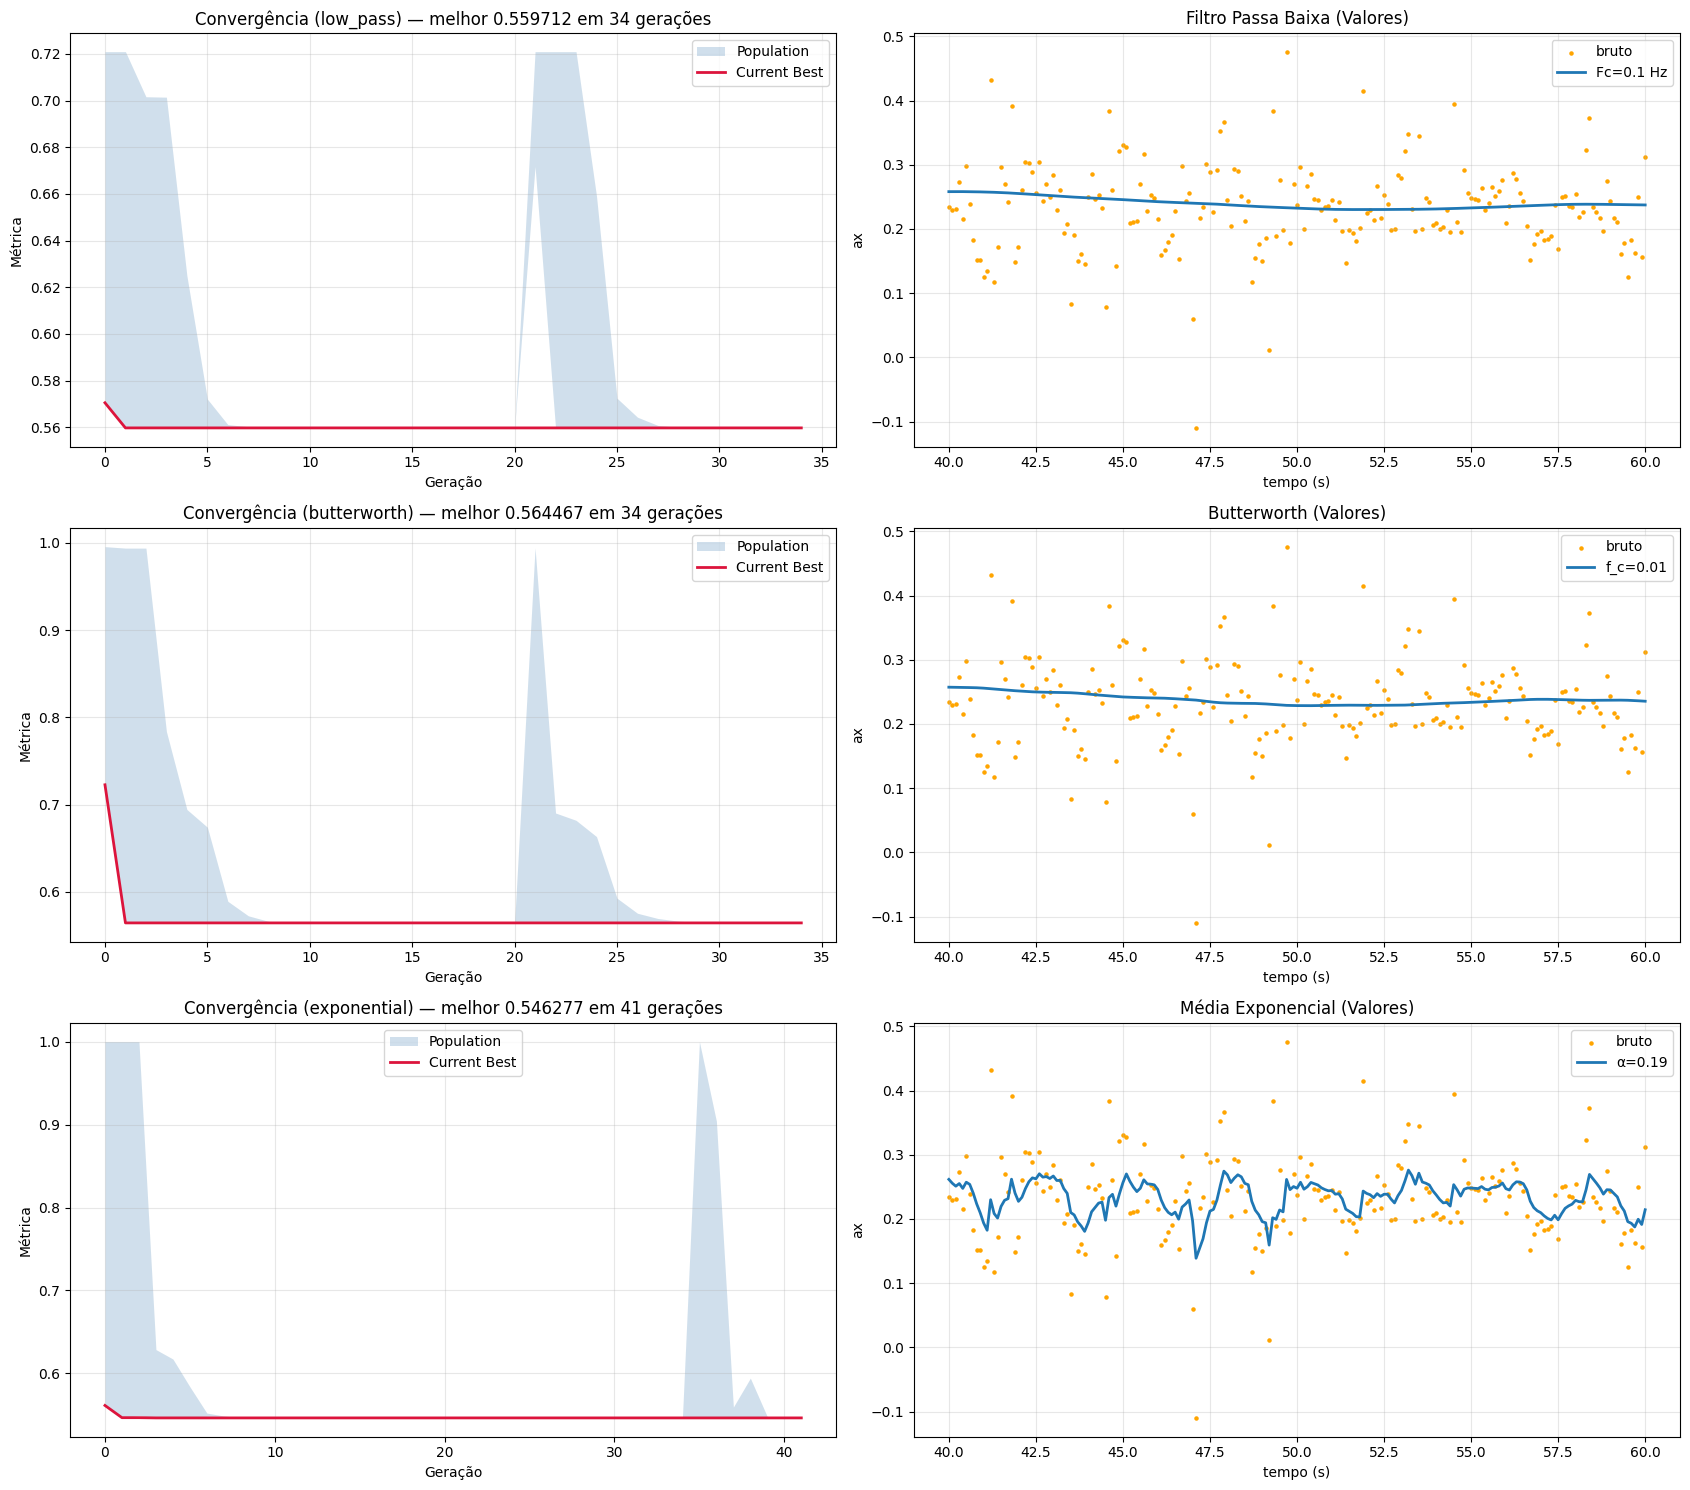

,error,params
exponential,0.546277,{'alpha': 0.1904697781848796}
low_pass,0.559712,{'Fc': 0.10000000001104986}
butterworth,0.564467,{'f_c': 0.01}


In [16]:
TARGET = 'ax'
models = {
    filter: NatureSelector('genetic', {
            'objective': lambda params, filter=filter: objective(filter, params),
            'maximize': False, 'verbose': True, 'variables': option['variables'], **SEARCH
        }, n_gaussian=RUNS
    ) for filter, option in FILTERS.items()
}

for model in models.values():
    model.update()


plt.figure(figsize=(17, 5*len(models)))
for i, (filter, model) in enumerate(models.items()):
    portrait      = model.portrait()
    portrait.name = filter    # O RETRATO VEM COM O NOME DO ALGORITMO, QUE É O MESMO NOS TRÊS

    plt.subplot(len(models), 2, 2*i + 1); portrait.metrics(plt.gca())
    plt.subplot(len(models), 2, 2*i + 2); FILTERS[filter]['filter'](**model.best).test(df[MOTION], TARGET, LIMITS)

plt.tight_layout()
plt.show()

rankings[TARGET] = {filter: {'error': model.score, 'params': model.best} for filter, model in models.items()}
pd.DataFrame(rankings[TARGET]).T.sort_values('error')

### ACELERAÇÃO EM Y ($a_y$)

genetic:   0%|          | 0/7500 [00:00<?, ?ev/s]

genetic:   1%|          | 60/7500 [00:00<00:37, 197.87ev/s, best=3.7346, pop=30]

genetic:   2%|▏         | 150/7500 [00:00<00:28, 256.06ev/s, best=3.7346, pop=30]

genetic:   3%|▎         | 240/7500 [00:00<00:26, 274.58ev/s, best=3.7346, pop=30]

genetic:   4%|▍         | 330/7500 [00:01<00:25, 283.86ev/s, best=3.7346, pop=30]

...

genetic:  80%|████████  | 6000/7500 [00:04<00:01, 1343.61ev/s, best=0.925741, pop=30]

genetic:  86%|████████▌ | 6420/7500 [00:04<00:00, 1355.55ev/s, best=0.925741, pop=30]

genetic:  91%|█████████ | 6840/7500 [00:05<00:00, 1365.37ev/s, best=0.925741, pop=30]

genetic:  97%|█████████▋| 7260/7500 [00:05<00:00, 1370.71ev/s, best=0.925741, pop=60]

genetic: 100%|██████████| 7260/7260 [00:05<00:00, 1360.87ev/s, best=0.925741, pop=60]

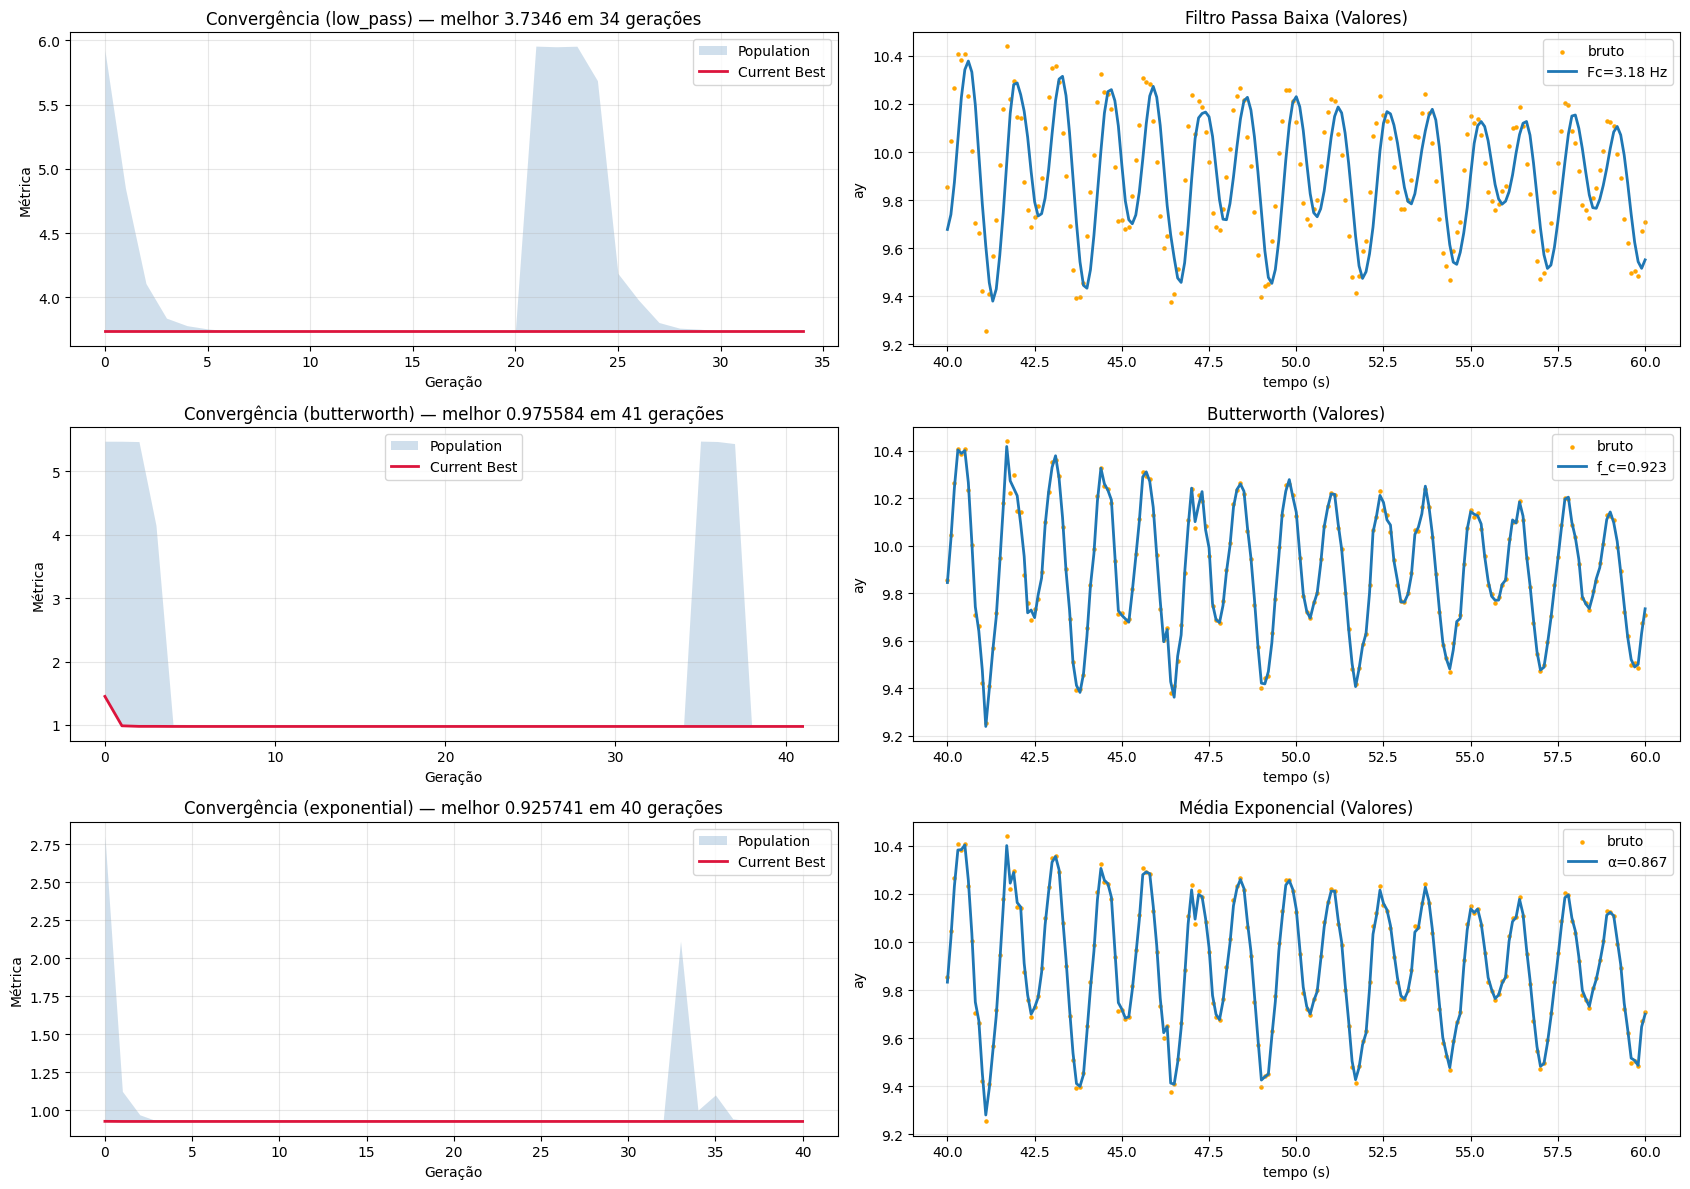

,error,params
exponential,0.925741,{'alpha': 0.8667028665915705}
butterworth,0.975584,{'f_c': 0.9227386811010561}
low_pass,3.734598,{'Fc': 3.183098861837907}


In [17]:
TARGET = 'ay'
models = {
    filter: NatureSelector('genetic', {
            'objective': lambda params, filter=filter: objective(filter, params),
            'maximize': False, 'verbose': True, 'variables': option['variables'], **SEARCH
        }, n_gaussian=RUNS
    ) for filter, option in FILTERS.items()
}

for model in models.values():
    model.update()

plt.figure(figsize=(17, 4*len(models)))
for i, (filter, model) in enumerate(models.items()):
    portrait      = model.portrait()
    portrait.name = filter 
    plt.subplot(len(models), 2, 2*i + 1); portrait.metrics(plt.gca())
    plt.subplot(len(models), 2, 2*i + 2); FILTERS[filter]['filter'](**model.best).test(df[MOTION], TARGET, LIMITS)

plt.tight_layout()
plt.show()

rankings[TARGET] = {filter: {'error': model.score, 'params': model.best} for filter, model in models.items()}
pd.DataFrame(rankings[TARGET]).T.sort_values('error')

### ACELERAÇÃO EM Z ($a_z$)

genetic:   0%|          | 0/7500 [00:00<?, ?ev/s]

genetic:   1%|          | 60/7500 [00:00<00:38, 195.34ev/s, best=1.01415, pop=30]

genetic:   2%|▏         | 150/7500 [00:00<00:28, 254.32ev/s, best=1.01415, pop=30]

genetic:   3%|▎         | 240/7500 [00:00<00:26, 271.36ev/s, best=1.01415, pop=30]

genetic:   4%|▍         | 330/7500 [00:01<00:25, 280.90ev/s, best=1.01415, pop=30]

...

genetic:  78%|███████▊  | 5820/7500 [00:04<00:01, 1396.15ev/s, best=0.714544, pop=60]

genetic:  83%|████████▎ | 6240/7500 [00:04<00:00, 1371.12ev/s, best=0.714544, pop=30]

genetic:  89%|████████▉ | 6690/7500 [00:04<00:00, 1381.96ev/s, best=0.714544, pop=30]

genetic:  95%|█████████▌| 7140/7500 [00:05<00:00, 1391.46ev/s, best=0.714544, pop=60]

genetic: 100%|██████████| 7260/7260 [00:05<00:00, 1377.00ev/s, best=0.714544, pop=60]

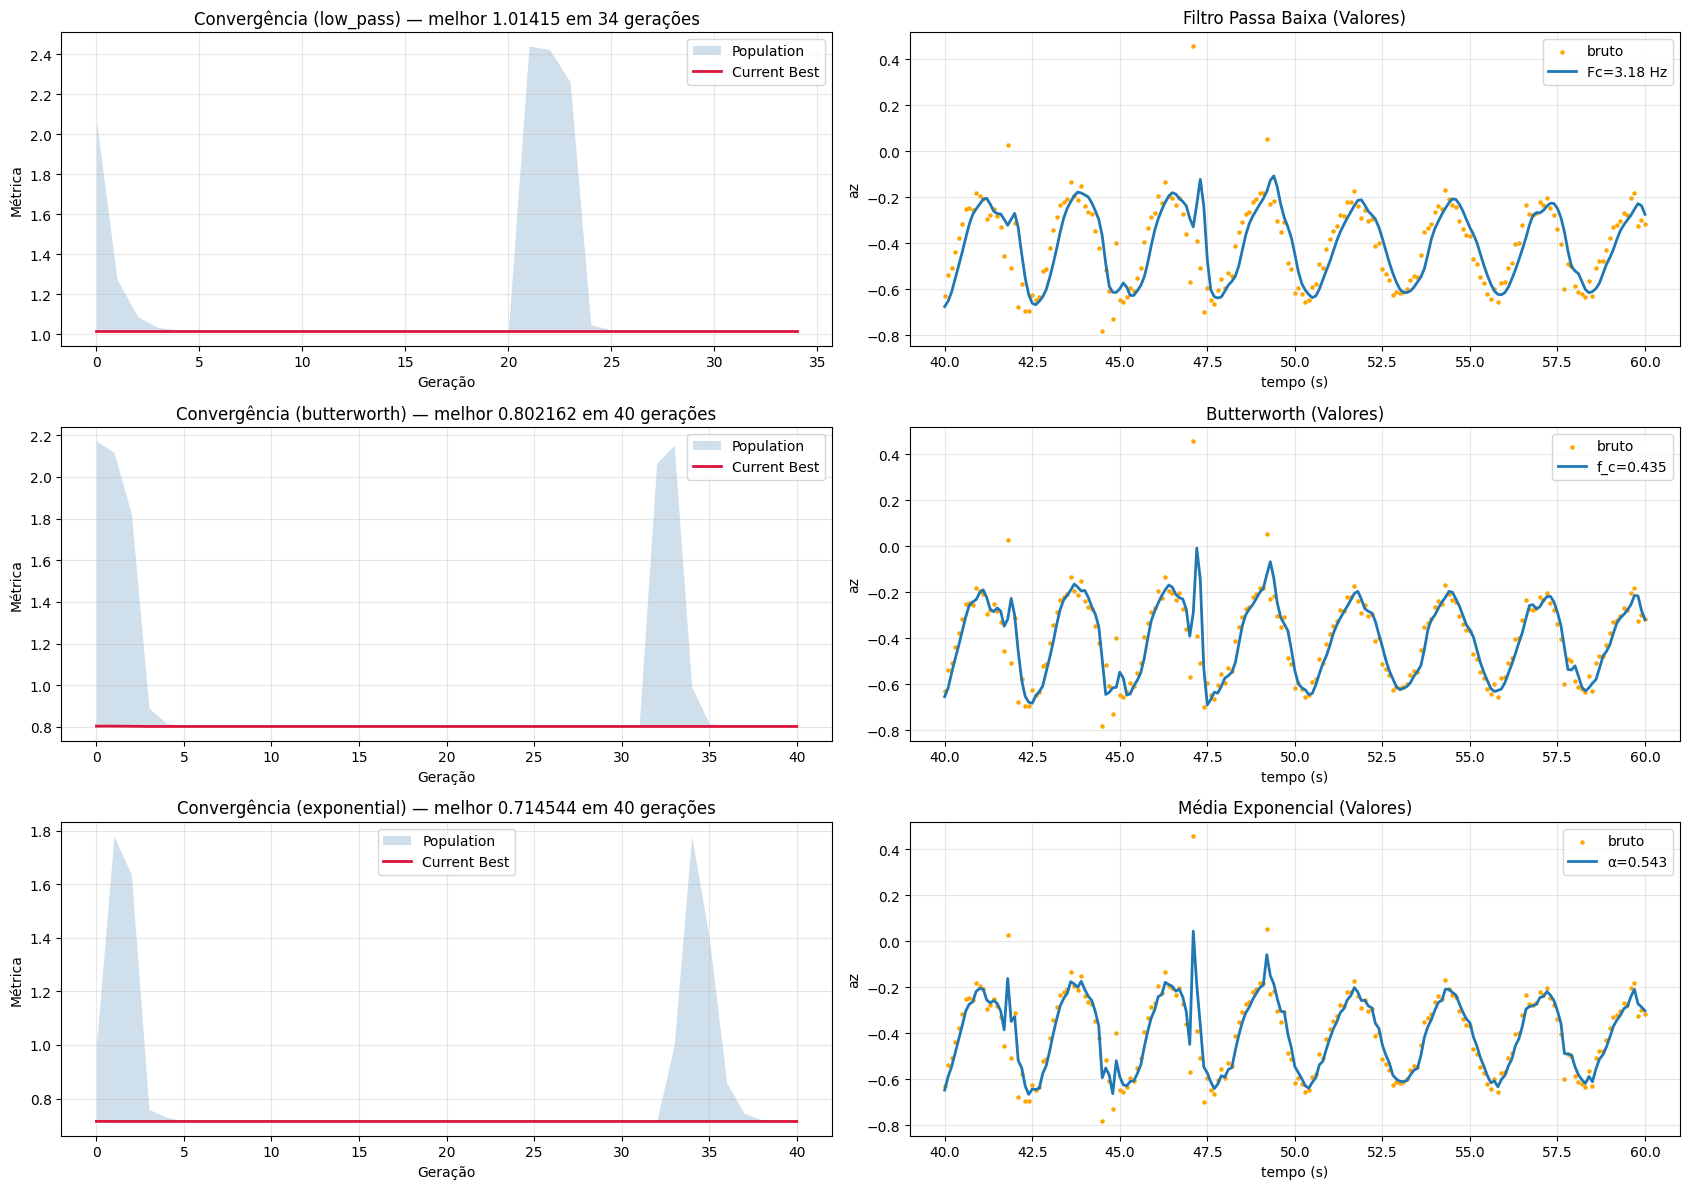

,error,params
exponential,0.714544,{'alpha': 0.5434603186755887}
butterworth,0.802162,{'f_c': 0.4351175413643629}
low_pass,1.014155,{'Fc': 3.183098861837907}


In [18]:
TARGET = 'az'
models = {
    filter: NatureSelector('genetic', {
            'objective': lambda params, filter=filter: objective(filter, params),
            'maximize': False, 'verbose': True, 'variables': option['variables'], **SEARCH
        }, n_gaussian=RUNS
    ) for filter, option in FILTERS.items()
}

for model in models.values():
    model.update()

plt.figure(figsize=(17, 4*len(models)))
for i, (filter, model) in enumerate(models.items()):
    portrait      = model.portrait()
    portrait.name = filter
    plt.subplot(len(models), 2, 2*i + 1); portrait.metrics(plt.gca())
    plt.subplot(len(models), 2, 2*i + 2); FILTERS[filter]['filter'](**model.best).test(df[MOTION], TARGET, LIMITS)

plt.tight_layout()
plt.show()

rankings[TARGET] = {filter: {'error': model.score, 'params': model.best} for filter, model in models.items()}
pd.DataFrame(rankings[TARGET]).T.sort_values('error')

### VELOCIDADE ANGULAR EM X ($\omega_x$)

genetic:   0%|          | 0/7500 [00:00<?, ?ev/s]

genetic:   1%|          | 60/7500 [00:00<00:38, 195.23ev/s, best=33.0277, pop=30]

genetic:   2%|▏         | 150/7500 [00:00<00:28, 253.91ev/s, best=33.0277, pop=30]

genetic:   3%|▎         | 240/7500 [00:00<00:26, 272.84ev/s, best=33.0277, pop=30]

genetic:   4%|▍         | 330/7500 [00:01<00:25, 281.17ev/s, best=33.0277, pop=30]

...

genetic:  77%|███████▋  | 5760/7500 [00:04<00:01, 1406.86ev/s, best=0.998262, pop=60]

genetic:  83%|████████▎ | 6210/7500 [00:04<00:00, 1380.88ev/s, best=0.998262, pop=30]

genetic:  89%|████████▉ | 6660/7500 [00:04<00:00, 1388.53ev/s, best=0.998262, pop=30]

genetic:  95%|█████████▌| 7140/7500 [00:05<00:00, 1394.23ev/s, best=0.998262, pop=60]

genetic: 100%|██████████| 7200/7200 [00:05<00:00, 1386.05ev/s, best=0.998262, pop=60]

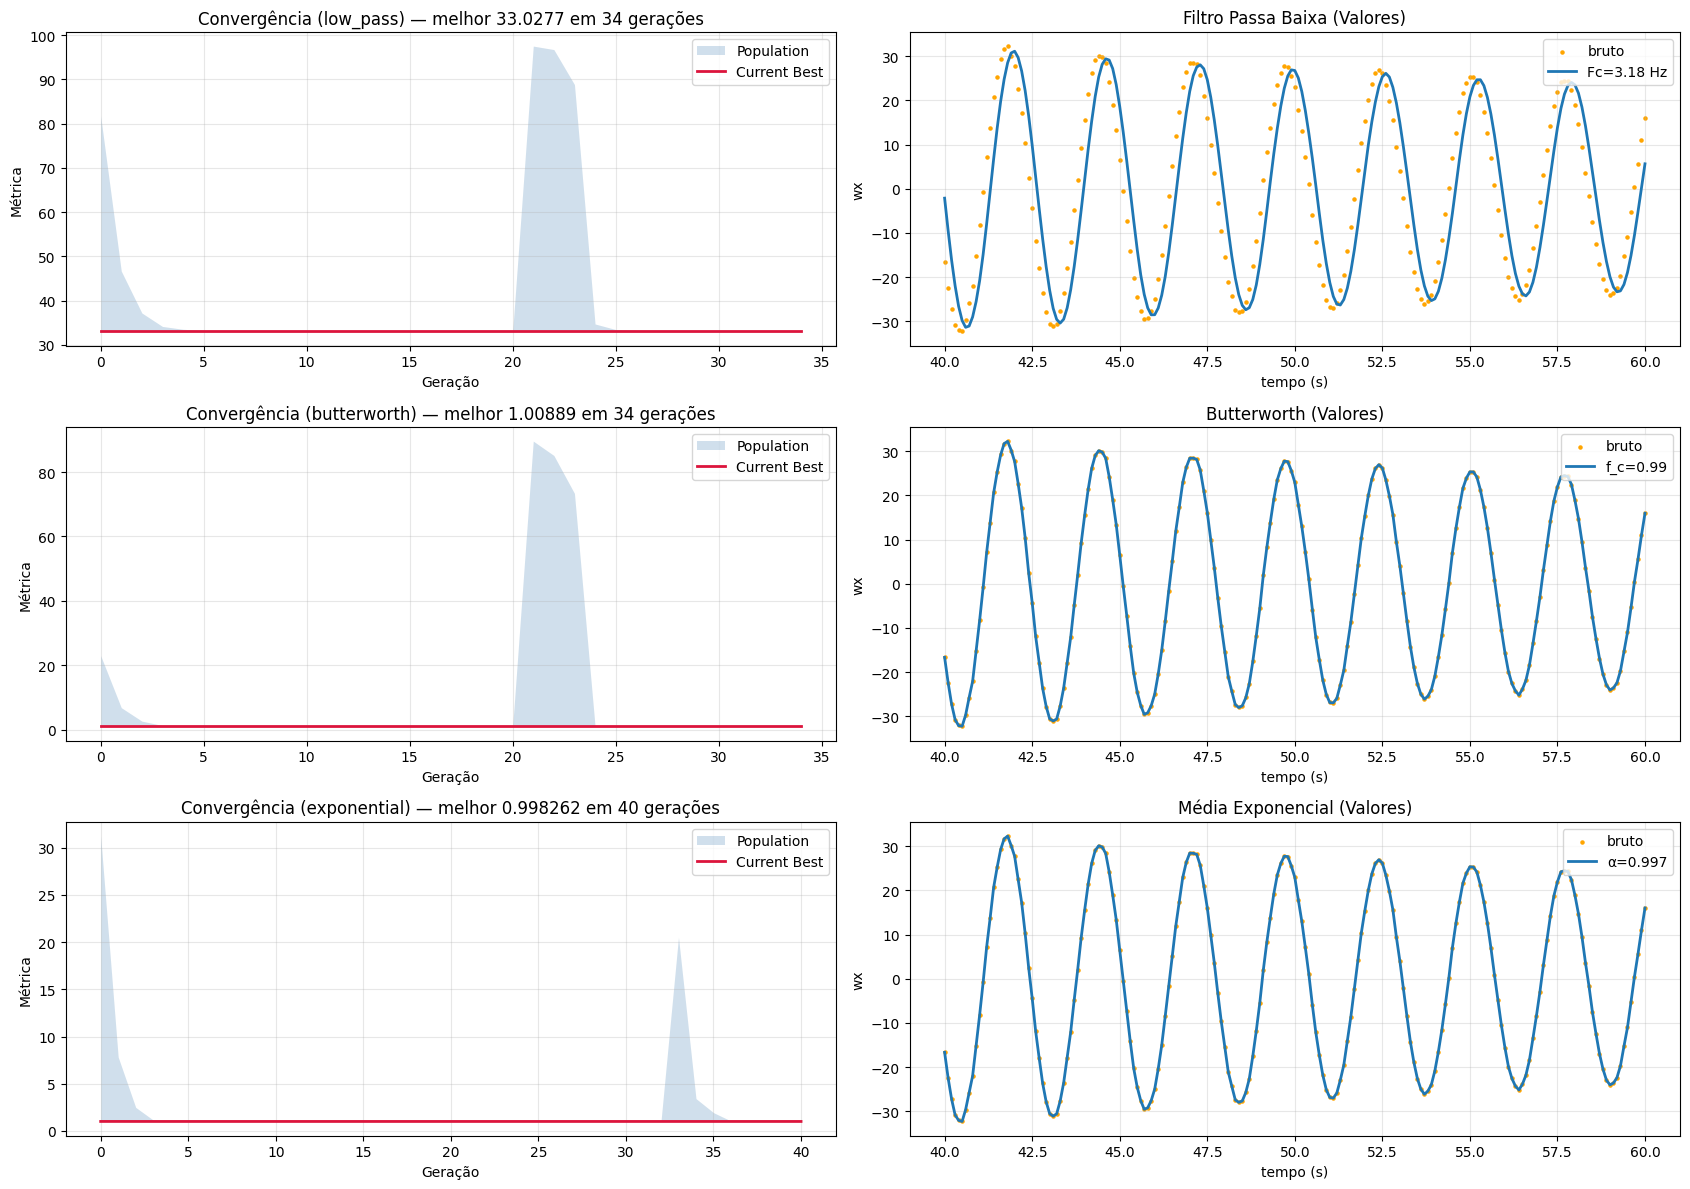

,error,params
exponential,0.998262,{'alpha': 0.9965391650368787}
butterworth,1.008894,{'f_c': 0.99}
low_pass,33.027732,{'Fc': 3.183098861837907}


In [19]:
TARGET = 'wx'
models = {
    filter: NatureSelector('genetic', {
            'objective': lambda params, filter=filter: objective(filter, params),
            'maximize': False, 'verbose': True, 'variables': option['variables'], **SEARCH
        }, n_gaussian=RUNS
    ) for filter, option in FILTERS.items()
}

for model in models.values():
    model.update()

plt.figure(figsize=(17, 4*len(models)))
for i, (filter, model) in enumerate(models.items()):
    portrait      = model.portrait()
    portrait.name = filter 
    plt.subplot(len(models), 2, 2*i + 1); portrait.metrics(plt.gca())
    plt.subplot(len(models), 2, 2*i + 2); FILTERS[filter]['filter'](**model.best).test(df[MOTION], TARGET, LIMITS)

plt.tight_layout()
plt.show()

rankings[TARGET] = {filter: {'error': model.score, 'params': model.best} for filter, model in models.items()}
pd.DataFrame(rankings[TARGET]).T.sort_values('error')

### VELOCIDADE ANGULAR EM Y ($\omega_y$)

genetic:   0%|          | 0/7500 [00:00<?, ?ev/s]

genetic:   1%|          | 60/7500 [00:00<00:39, 190.21ev/s, best=0.89185, pop=30]

genetic:   2%|▏         | 150/7500 [00:00<00:29, 250.90ev/s, best=0.89185, pop=30]

genetic:   3%|▎         | 240/7500 [00:00<00:26, 272.17ev/s, best=0.89185, pop=30]

genetic:   4%|▍         | 330/7500 [00:01<00:25, 281.75ev/s, best=0.89185, pop=30]

...

genetic:  76%|███████▋  | 5730/7500 [00:04<00:01, 1380.51ev/s, best=0.67674, pop=60]

genetic:  82%|████████▏ | 6150/7500 [00:04<00:00, 1354.51ev/s, best=0.67674, pop=30]

genetic:  88%|████████▊ | 6570/7500 [00:04<00:00, 1365.68ev/s, best=0.67674, pop=30]

genetic:  94%|█████████▎| 7020/7500 [00:05<00:00, 1375.02ev/s, best=0.67674, pop=60]

genetic: 100%|██████████| 7320/7320 [00:05<00:00, 1366.85ev/s, best=0.67674, pop=60]

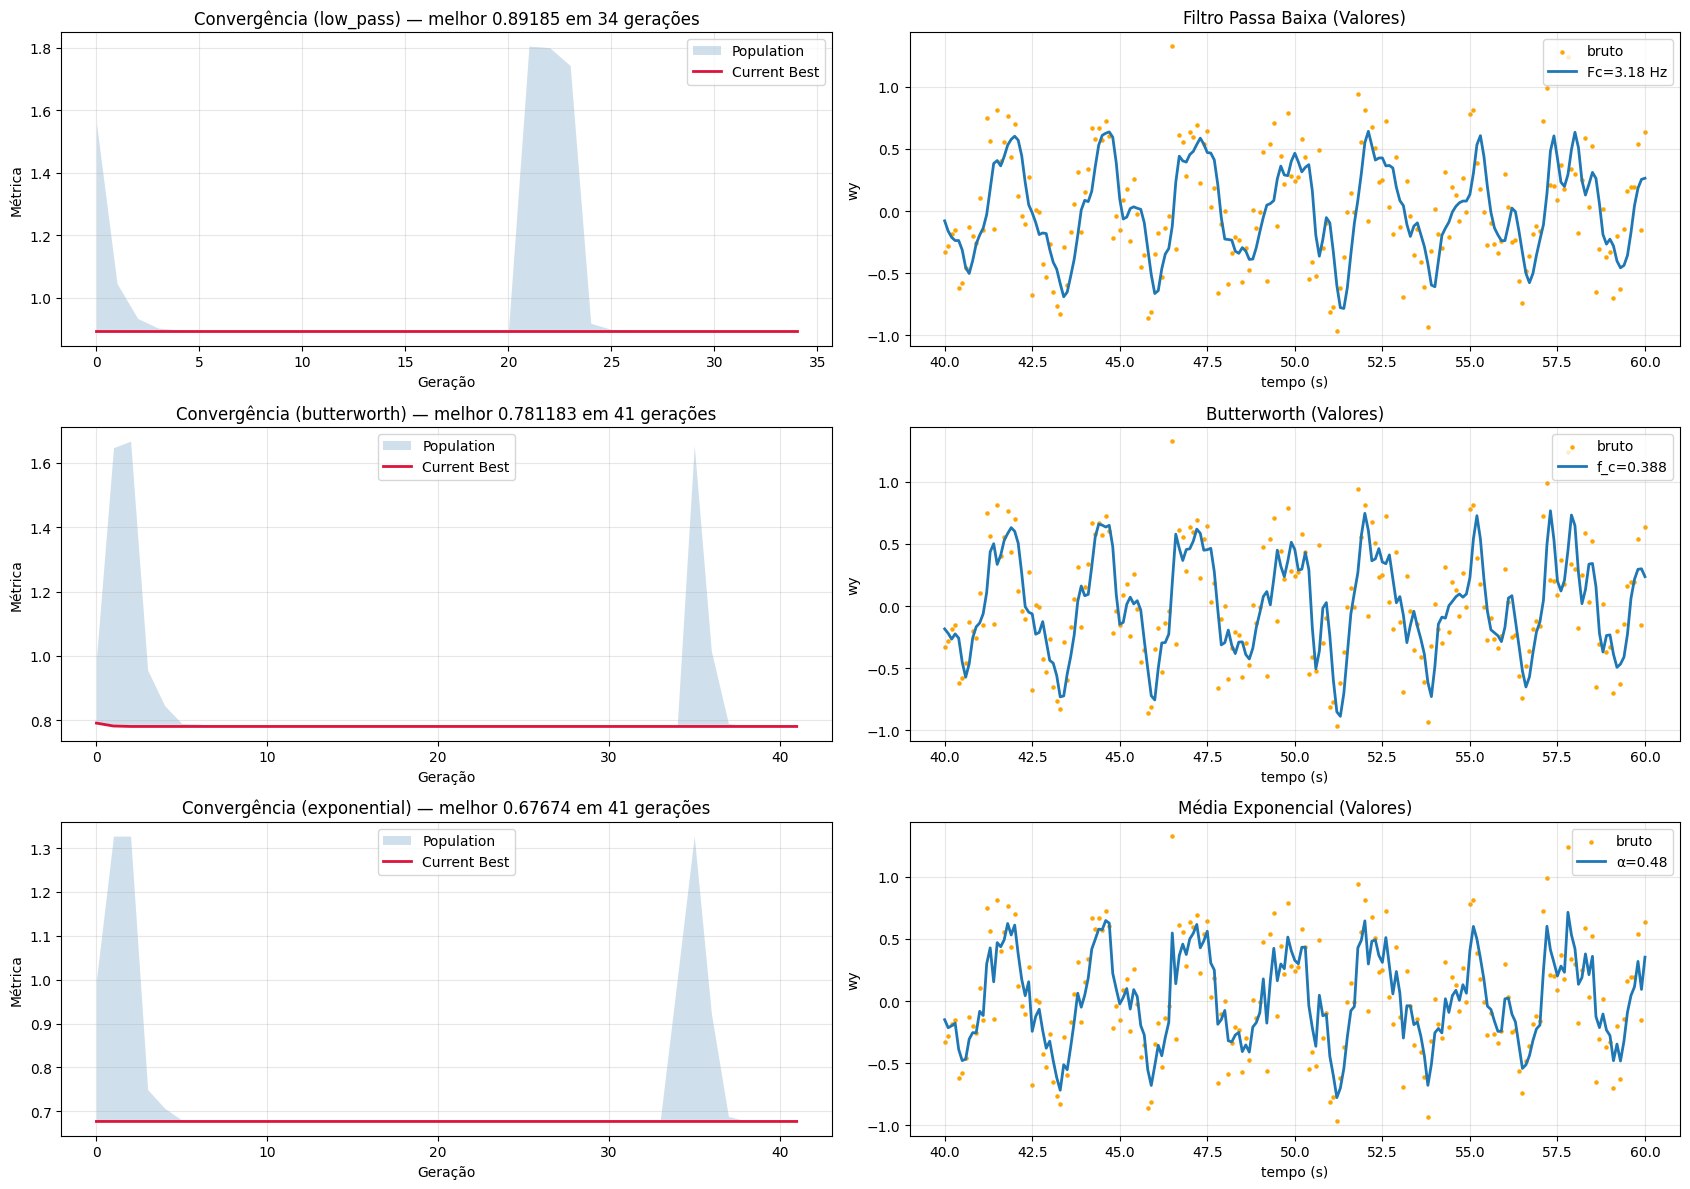

,error,params
exponential,0.67674,{'alpha': 0.47979039702982246}
butterworth,0.781183,{'f_c': 0.388474766337821}
low_pass,0.89185,{'Fc': 3.183098861837907}


In [20]:
TARGET = 'wy'
models = {
    filter: NatureSelector('genetic', {
            'objective': lambda params, filter=filter: objective(filter, params),
            'maximize': False, 'verbose': True, 'variables': option['variables'], **SEARCH
        }, n_gaussian=RUNS
    ) for filter, option in FILTERS.items()
}

for model in models.values():
    model.update()


plt.figure(figsize=(17, 4*len(models)))

for i, (filter, model) in enumerate(models.items()):
    portrait      = model.portrait()
    portrait.name = filter 
    plt.subplot(len(models), 2, 2*i + 1); portrait.metrics(plt.gca())
    plt.subplot(len(models), 2, 2*i + 2); FILTERS[filter]['filter'](**model.best).test(df[MOTION], TARGET, LIMITS)

plt.tight_layout(); plt.show()

rankings[TARGET] = {filter: {'error': model.score, 'params': model.best} for filter, model in models.items()}
pd.DataFrame(rankings[TARGET]).T.sort_values('error')

### VELOCIDADE ANGULAR EM Z ($\omega_z$)

genetic:   0%|          | 0/7500 [00:00<?, ?ev/s]

genetic:   1%|          | 60/7500 [00:00<00:38, 192.91ev/s, best=5.83815, pop=30]

genetic:   2%|▏         | 150/7500 [00:00<00:29, 250.69ev/s, best=5.83815, pop=30]

genetic:   3%|▎         | 240/7500 [00:00<00:26, 269.81ev/s, best=5.83815, pop=30]

genetic:   4%|▍         | 330/7500 [00:01<00:25, 278.22ev/s, best=5.83815, pop=30]

...

genetic:  75%|███████▌  | 5640/7500 [00:04<00:01, 1398.93ev/s, best=0.958488, pop=60]

genetic:  81%|████████  | 6060/7500 [00:04<00:01, 1379.87ev/s, best=0.958488, pop=30]

genetic:  87%|████████▋ | 6510/7500 [00:04<00:00, 1390.80ev/s, best=0.958488, pop=30]

genetic:  93%|█████████▎| 6960/7500 [00:05<00:00, 1398.51ev/s, best=0.958488, pop=60]

genetic: 100%|██████████| 7200/7200 [00:05<00:00, 1383.38ev/s, best=0.958488, pop=60]

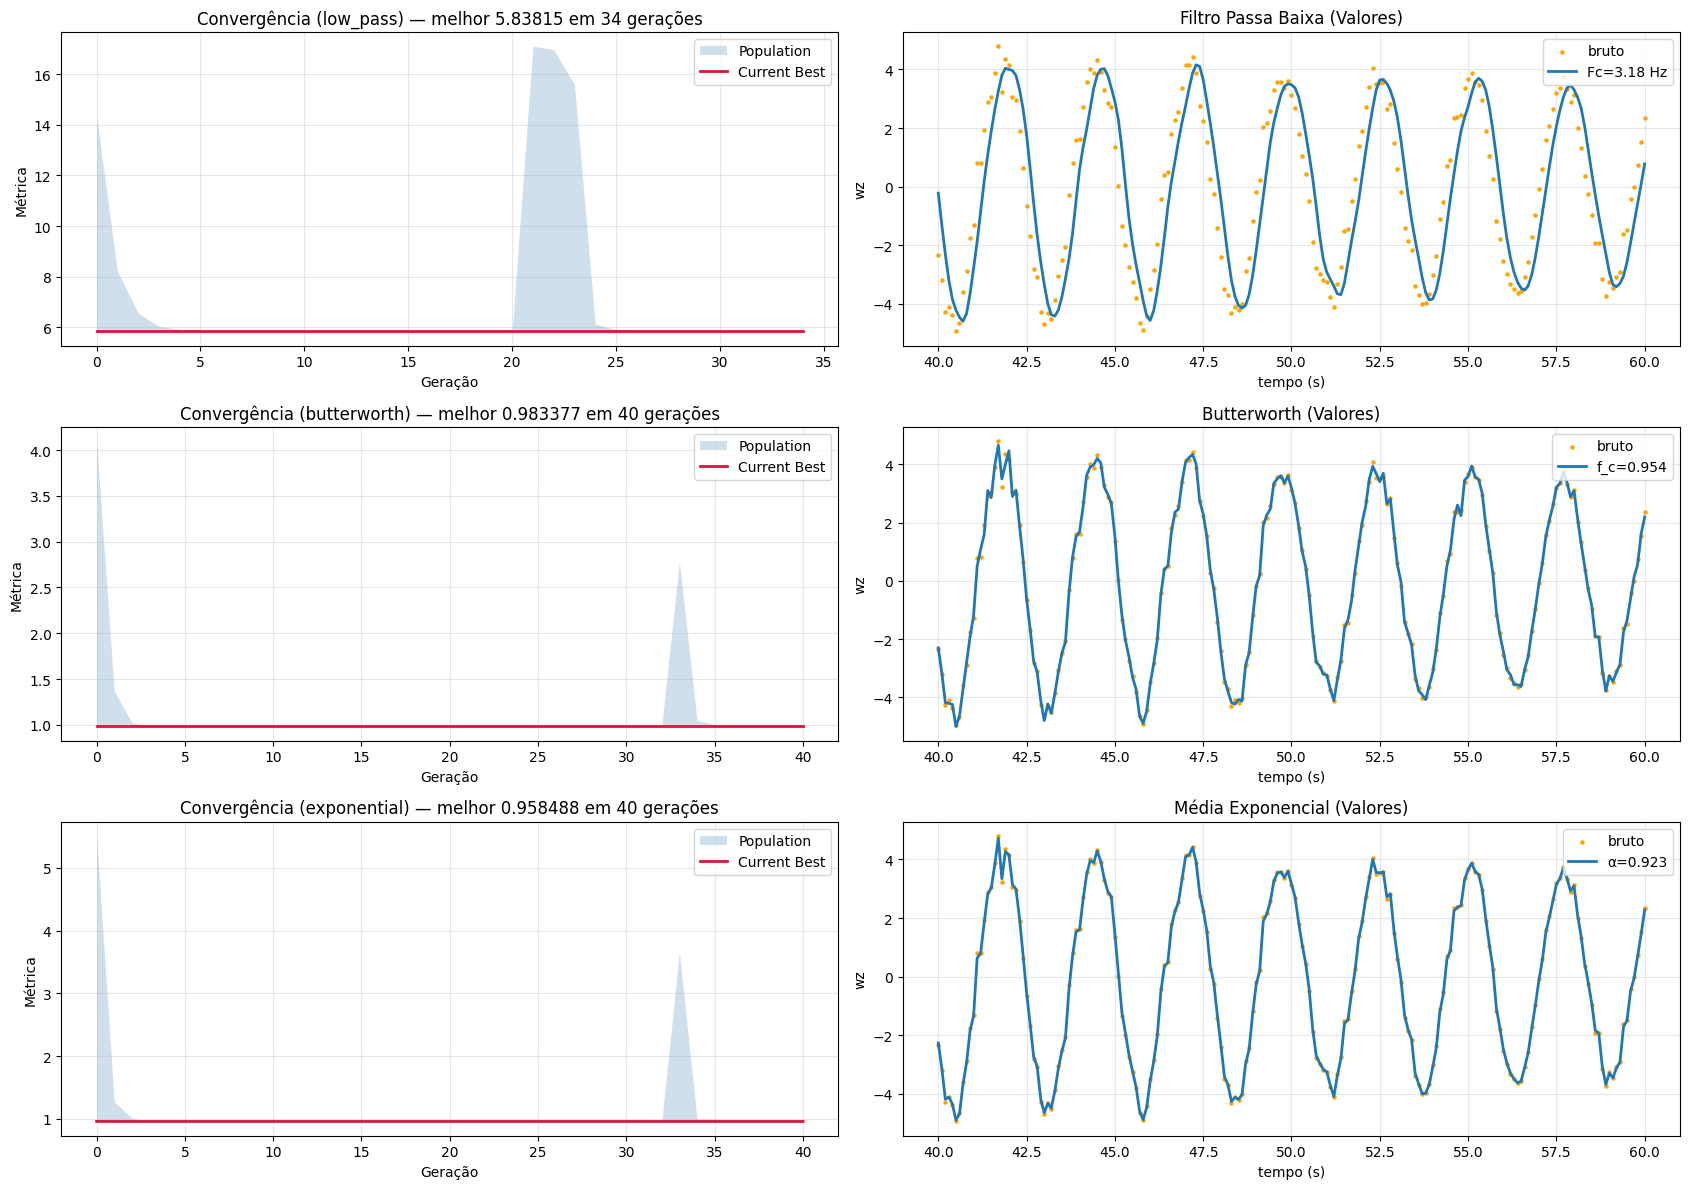

,error,params
exponential,0.958488,{'alpha': 0.923136961958569}
butterworth,0.983377,{'f_c': 0.954084719265417}
low_pass,5.838149,{'Fc': 3.183098861837907}


In [21]:
TARGET = 'wz'
models = {
    filter: NatureSelector('genetic', {
            'objective': lambda params, filter=filter: objective(filter, params),
            'maximize': False, 'verbose': True, 'variables': option['variables'], **SEARCH
        }, n_gaussian=RUNS
    ) for filter, option in FILTERS.items()
}

for model in models.values():
    model.update()

plt.figure(figsize=(17, 4*len(models)))
for i, (filter, model) in enumerate(models.items()):
    portrait      = model.portrait()
    portrait.name = filter  
    plt.subplot(len(models), 2, 2*i + 1); portrait.metrics(plt.gca())
    plt.subplot(len(models), 2, 2*i + 2); FILTERS[filter]['filter'](**model.best).test(df[MOTION], TARGET, LIMITS)

plt.tight_layout()
plt.show()

rankings[TARGET] = {filter: {'error': model.score, 'params': model.best} for filter, model in models.items()}
pd.DataFrame(rankings[TARGET]).T.sort_values('error')

# ESCOLHA DO MELHOR FILTRO
- A escolha é pela métrica: $\varepsilon$ é objetivo, relativo ao sinal cru, e escolher no olho entre 3 filtros × 6 variáveis não seria reprodutível; os gráficos de cada variável ficam como conferência
- Com $\varepsilon$ perto de 1 filtrar em tempo real não compensa, e o firmware fica sem filtro (`fc = 0`)

In [22]:
CHOSEN = {
    'ax': 'exponential',
    'ay': 'low_pass',
    'az': 'butterworth',
    'wx': 'exponential',
    'wy': 'butterworth',
    'wz': 'low_pass'
}

chosen = {}
for var, filter in CHOSEN.items():
    chosen[var] = {
        'name': filter,
        'error': rankings[var][filter]['error'],
        'params': rankings[var][filter]['params']
    }

chosen = pd.DataFrame(chosen).T
chosen

,name,error,params
ax,exponential,0.546277,{'alpha': 0.1904697781848796}
ay,low_pass,3.734598,{'Fc': 3.183098861837907}
az,butterworth,0.802162,{'f_c': 0.4351175413643629}
wx,exponential,0.998262,{'alpha': 0.9965391650368787}
wy,butterworth,0.781183,{'f_c': 0.388474766337821}
wz,low_pass,5.838149,{'Fc': 3.183098861837907}


# SALVANDO OS FILTROS

In [23]:
df = df.rename(columns={col: f'{col}_raw' for col in SENSORS})

for var, row in chosen.iterrows():
    df[var] = FILTERS[row['name']]['filter'](**row['params']).apply(df[f'{var}_raw'])

os.makedirs(RESULTS, exist_ok=True)
df.to_csv(f'{RESULTS}/filtered.csv', index=None)
df

,time,static,ax_raw,ay_raw,az_raw,wx_raw,wy_raw,wz_raw,ax,ay,az,wx,wy,wz
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.194623,10.733555,-0.614769,-47.929600,-1.167260,-6.924550
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.213688,10.788869,-0.595396,-58.100588,-1.146087,-7.000029
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.221923,11.090177,-0.971534,-67.499878,-1.270851,-7.320063
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.260607,11.711480,-1.446905,-67.392892,-1.481145,-7.939093
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.262625,12.287115,-0.978232,-66.627677,-1.547993,-8.694823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2794,279.4,True,0.269369,9.760873,-0.416959,-0.09321,0.25104,-0.21920,0.232621,9.767762,-0.433973,-0.093299,0.055385,0.044324
2795,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493,0.233253,9.742458,-0.412662,-0.099269,0.131128,0.034890
2796,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338,0.237808,9.736801,-0.402890,-0.185670,0.157085,0.004759
2797,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588,0.243282,9.745389,-0.421209,0.065049,0.160550,0.093241


In [24]:
os.makedirs('Backup', exist_ok=True)
saved  = [name for name in os.listdir('Backup') if name.startswith('filters_')]    # O target.csv TEMPORÁRIO TAMBÉM MORA NO Backup
index  = len(saved) + 1

output = f'Backup/filters_{index}'
os.makedirs(output, exist_ok=True)

results = {
    'filters':  chosen.to_dict('index'),
    'ranking':  rankings,
    'search':   {**SEARCH, 'runs': RUNS, 'variables': {name: option['variables'] for name, option in FILTERS.items()}},
    'dataset':  {'path': DATASET, 'samples': int(MOTION.sum()), 'dt': float(dt)}
}

record = {
    'strategy': 'filters',
    'backup':   f'Filters/{output}',
    'filters':  {var: {'name': row['name'], 'error': row['error']} for var, row in chosen.iterrows()}
}

pd.Series(results).to_json(f'{output}/info.json', indent=4)
pd.Series(record).to_json(f'{RESULTS}/filters.json', indent=4)
print(output, '->', f'{RESULTS}/filters.json')
record

Backup/filters_2 -> ../Dataset/test1/results/filters.json


{'strategy': 'filters',
 'backup': 'Filters/Backup/filters_2',
 'filters': {'ax': {'name': 'exponential', 'error': 0.546277362389636},
  'ay': {'name': 'low_pass', 'error': 3.734598498798147},
  'az': {'name': 'butterworth', 'error': 0.8021623292692138},
  'wx': {'name': 'exponential', 'error': 0.9982623259614705},
  'wy': {'name': 'butterworth', 'error': 0.7811827697283582},
  'wz': {'name': 'low_pass', 'error': 5.838148504053745}}}

# EXPORTANDO PARA O FIRMWARE
- O MRU filtra com o Butterworth, o mesmo que roda aqui; do ensaio sai só o corte de cada eixo
- O corte vai em Hz: aqui a amostragem é de 10 Hz e lá é a do Kernel, então a fração de Nyquist não se transporta

In [23]:
FIRMWARE = '../../Hardware/Embedded/Main/objects/processing/filters/butterworth'
NYQUIST  = 0.5 / dt

cutoff = {var: rankings[var]['butterworth']['params']['f_c'] * NYQUIST for var in SENSORS}
values = ', '.join(f'{cutoff[var]:.6f}f' for var in SENSORS)

header = f'''#ifndef BUTTERWORTH_CONFIG_H
#define BUTTERWORTH_CONFIG_H

// GERADO POR Calibration/Filters/1 - Model.ipynb EM {datetime.date.today():%d/%m/%Y}
static const float BUTTERWORTH_FC[6] = {{{values}}};    // corte de -3 dB em Hz: {', '.join(SENSORS)}

#endif
'''

os.makedirs(FIRMWARE, exist_ok=True)
open(f'{FIRMWARE}/config.h', 'w').write(header)

print(f'{FIRMWARE}/config.h')
display(pd.DataFrame({'corte (Hz)': cutoff, 'erro': {var: rankings[var]['butterworth']['error'] for var in SENSORS}}))
print(header)

../../Hardware/Embedded/Main/objects/processing/filters/butterworth/config.h


,corte (Hz),erro
ax,0.050000,0.564467
ay,4.613693,0.975584
az,2.175588,0.802162
wx,4.950000,1.008894
wy,1.942374,0.781183
wz,4.770424,0.983377


#ifndef BUTTERWORTH_CONFIG_H
#define BUTTERWORTH_CONFIG_H

// GERADO POR Calibration/Filters/1 - Model.ipynb EM 22/09/2026
static const float BUTTERWORTH_FC[6] = {0.050000f, 4.613693f, 2.175588f, 4.950000f, 1.942374f, 4.770424f};    // corte de -3 dB em Hz: ax, ay, az, wx, wy, wz

#endif

